# 10 — `ModulationIndex` (Tort 2010 KL-divergence MI)

Computes MI between phase and amplitude tensors shaped
`(B, C, F_pha, n_segments, T)` and `(B, C, F_amp, n_segments, T)`.
MI ∈ [0, 1]: KL-divergence between the observed amplitude
distribution over phase bins and uniform, normalised by `log(n_bins)`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import butter, filtfilt
from scipy.signal import hilbert as scipy_hilbert

import scitex_nn

rng = np.random.default_rng(0)
fs, duration = 500, 6.0
seq_len = int(fs * duration)
t = np.arange(seq_len) / fs


def bp(x, lo, hi, order=4):
    b, a = butter(order, [lo, hi], btype="band", fs=fs)
    return filtfilt(b, a, x).copy()


# Coupled vs uncoupled theta-gamma signal
theta = np.sin(2 * np.pi * 6 * t)
env = 1 + 0.8 * (theta + 1) / 2
gamma_c = env * np.sin(2 * np.pi * 60 * t)
sig_c = theta + gamma_c + 0.05 * rng.standard_normal(seq_len)
sig_u = theta + np.sin(2 * np.pi * 60 * t) + 0.05 * rng.standard_normal(seq_len)


def mi_of(sig):
    pha = np.angle(scipy_hilbert(bp(sig, 4.5, 7.5)))
    amp = np.abs(scipy_hilbert(bp(sig, 50, 70)))
    pha_t = torch.from_numpy(pha).float().view(1, 1, 1, 1, seq_len)
    amp_t = torch.from_numpy(amp).float().view(1, 1, 1, 1, seq_len)
    return float(scitex_nn.ModulationIndex(n_bins=18)(pha_t, amp_t).item())


mi_c, mi_u = mi_of(sig_c), mi_of(sig_u)
print(f"MI coupled   = {mi_c:.4f}")
print(f"MI uncoupled = {mi_u:.4f}")
assert mi_c > mi_u, "coupled MI must exceed uncoupled MI"

MI coupled   = 0.0069
MI uncoupled = 0.0000


## Side-by-side time traces

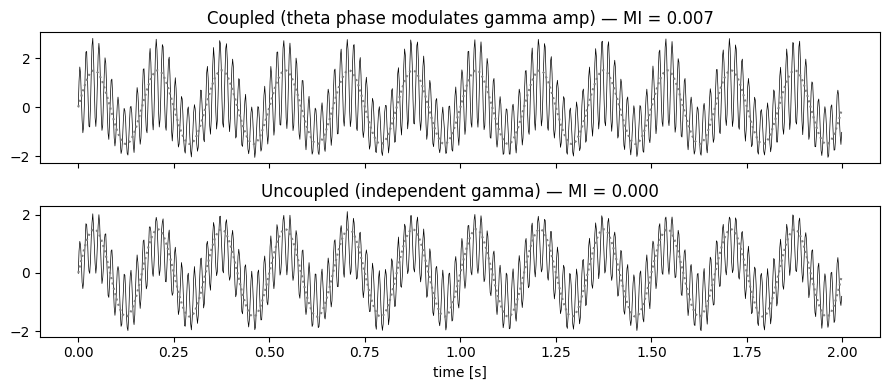

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
n_show = 2 * fs
axes[0].plot(t[:n_show], sig_c[:n_show], "k", lw=0.5)
axes[0].plot(t[:n_show], theta[:n_show] * 1.5, "grey", ls=":")
axes[0].set_title(f"Coupled (theta phase modulates gamma amp) — MI = {mi_c:.3f}")
axes[1].plot(t[:n_show], sig_u[:n_show], "k", lw=0.5)
axes[1].plot(t[:n_show], theta[:n_show] * 1.5, "grey", ls=":")
axes[1].set_xlabel("time [s]")
axes[1].set_title(f"Uncoupled (independent gamma) — MI = {mi_u:.3f}")
fig.tight_layout()
plt.show()